In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
dataset=pd.read_csv("C:/Users/soham/OneDrive/Desktop/Stress_level_prediction/artifacts/rawdata.csv")

In [3]:
dataset.shape

(1100, 21)

In [4]:
dataset.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [5]:
dataset.isnull().sum()

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

In [6]:
dataset.duplicated().sum()

np.int64(0)

In [7]:
dataset.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


In [8]:
categorical_coulms=dataset.select_dtypes(include='object').columns.tolist()
categorical_coulms

[]

In [9]:
boolean_columns=dataset.select_dtypes(include='bool').columns.tolist()
boolean_columns

[]

In [10]:
colums=dataset.columns
colums


Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'academic_performance', 'study_load', 'teacher_student_relationship',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying', 'stress_level'],
      dtype='object')

In [11]:
unique=dict()
for i in colums:
    unique[i]=dataset[i].unique()

unique

{'anxiety_level': array([14, 15, 12, 16, 20,  4, 17, 13,  6,  5,  9,  2, 11,  7, 21,  3, 18,
         0,  8,  1, 19, 10]),
 'self_esteem': array([20,  8, 18, 12, 28, 13, 26,  3, 22, 15, 23, 21, 25,  1, 27,  5,  6,
         9, 29, 30,  4, 19, 16,  2,  0, 14,  7, 17, 24, 11, 10]),
 'mental_health_history': array([0, 1]),
 'depression': array([11, 15, 14,  7, 21,  6, 22, 12, 27, 25,  8, 24,  3,  1,  0,  5, 26,
        20, 10,  9,  2, 16,  4, 13, 18, 23, 17, 19]),
 'headache': array([2, 5, 4, 3, 1, 0]),
 'blood_pressure': array([1, 3, 2]),
 'sleep_quality': array([2, 1, 5, 4, 3, 0]),
 'breathing_problem': array([4, 2, 3, 1, 5, 0]),
 'noise_level': array([2, 3, 4, 1, 0, 5]),
 'living_conditions': array([3, 1, 2, 4, 5, 0]),
 'safety': array([3, 2, 4, 1, 5, 0]),
 'basic_needs': array([2, 3, 1, 4, 5, 0]),
 'academic_performance': array([3, 1, 2, 4, 5, 0]),
 'study_load': array([2, 4, 3, 5, 1, 0]),
 'teacher_student_relationship': array([3, 1, 2, 4, 5, 0]),
 'future_career_concerns': array([3, 

In [12]:
corr=dataset.corr()

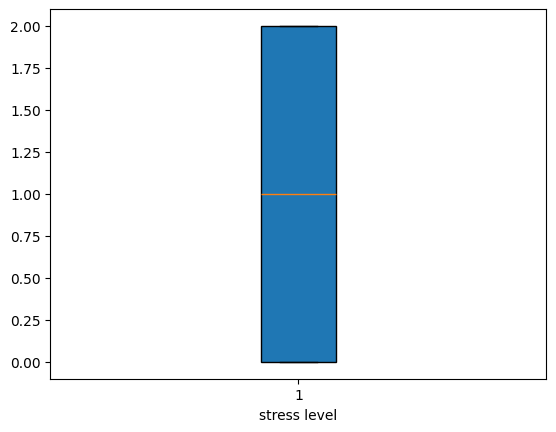

In [13]:
plt.boxplot(dataset['stress_level'],patch_artist=True)
plt.xlabel("stress level")
plt.show()

In [14]:
fig=px.bar(
    data_frame=dataset,
    x='stress_level',
    y='anxiety_level',
    labels={'stress_level':"Stress Level",'anxiety_level':"Anxiety Level"},
    color='stress_level',
    category_orders={'stress_level':[0,1,2]},
    )
fig.update_yaxes(range=[1,21])
fig.update_xaxes(tickvals=[0,1,2])
fig.show()

In [15]:
fig=px.histogram(
    data_frame=dataset,
    x=dataset['stress_level'],
    color='stress_level',
    )
fig.update_xaxes(tickvals=[0,1,2])
fig.show()

In [16]:
fig=px.line(dataset,y=dataset['stress_level'],x=dataset['anxiety_level'],color='anxiety_level')
fig.update_yaxes(tickvals=[0,1,2])
fig.show()

In [22]:
dataset=dataset.drop(columns=['academic_performance', 'study_load', 'teacher_student_relationship'],axis=1)
dataset.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,3,2,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,2,2,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,3,2,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,2,2,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,4,3,2,1,5,0,5,1


In [23]:
dataset.columns

Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying', 'stress_level'],
      dtype='object')